# About Dataset
Datasets acquired:
EMOPIA - a shared multi-modal (audio and MIDI) database focusing on perceived emotion in pop piano music, to facilitate research on various tasks related to music emotion. 

### Context:
Generate MIDI based on their arousal and valence position where:
1. Q1: High valence, high arousal
2. Q2: Low valence, high arousal
3. Q3: low valence, low arousal
4. Q4: High valence, low arousal

In [2]:
import os
import sys
from dotenv import load_dotenv
load_dotenv()


sys.path.insert(0, os.getenv("PYTHONPATH"))

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats 
import re
import matplotlib.pyplot as plt
import pretty_midi
from mido import MidiFile, MidiTrack, Message
from IPython.display import Audio
from music21 import *

## EDA for EMOPIA Dataset

### Metadata Analysis

`label.csv` contains the which annotator, audio IDs, and the dominant quadrant for each ID
`metadata_by_song` shows the number of annotators for each song and which are the majority vote AV quadtrant across annotators

In [8]:
# Load dataset
df_emopia = pd.read_csv('./data/emopia/label.csv')
df_emopia.head()


,ID,4Q,annotator
0,Q1_0vLPYiPN7qY_0,1,D
1,Q1_0vLPYiPN7qY_1,1,D
2,Q1_0vLPYiPN7qY_2,1,D
3,Q1_1Qc15G0ZHIg_1,1,D
4,Q1_1Qc15G0ZHIg_2,1,D


In [9]:
df_metadata_emopia = pd.read_csv('./data/emopia/metadata_by_song.csv')
df_metadata_emopia.head()

,songID,num_Q1,num_Q2,num_Q3,num_Q4,DominantQ
0,e8NQ2NH0nc8,2,0,0,0,1
1,HQ8ISDX6PiI,0,0,0,2,4
2,ZTrEoB8T9YA,0,3,0,0,2
3,3N2G21U7guk,3,0,0,4,4
4,_8v0MFBZoco,2,0,0,0,1


In [10]:
# Most songs have sparse votes — worth checking how many total votes per song
df_metadata_emopia['total_votes'] = df_metadata_emopia[['num_Q1','num_Q2','num_Q3','num_Q4']].sum(axis=1)
df_metadata_emopia['total_votes'].describe()

# Count how may songs have 0, 1, 2, 3, or 4 votes
for i in range(5):
    print(f"Number of songs with {i} votes: {(df_metadata_emopia['total_votes'] == i).sum()}")


Number of songs with 0 votes: 0
Number of songs with 1 votes: 65
Number of songs with 2 votes: 135
Number of songs with 3 votes: 115
Number of songs with 4 votes: 40


In [12]:
df_metadata_emopia[['num_Q1','num_Q2','num_Q3','num_Q4']].describe()

,num_Q1,num_Q2,num_Q3,num_Q4
count,387.000000,387.000000,387.000000,387.000000
mean,0.645995,0.684755,0.653747,0.801034
std,1.375678,1.332670,1.395405,1.250575
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,2.000000
max,14.000000,10.000000,14.000000,10.000000


- Higher standard deviation (1.250575 - 1.395405) than the mean (0.645995 - 0.801034) suggests high variability and potential outliers. 
- More than 75% of the dataset has either 1 or 2 annotators for each song.
- No missing values in the subset.
- A few songs are extremely categorised in Q1 and Q3.
- Q4 has a higher mean, lower srandard deviation, and 1 or 2 votes in any other category, which suggests potential bias for the model to predict quadrant 4.


In [13]:
# Which quadrant is the most dominant in the dataset
quadrant_counts = df_metadata_emopia['DominantQ'].value_counts()
percentage = quadrant_counts / len(df_metadata_emopia) * 100
print("Quadrant distribution:")
print(f"{round(percentage, 2)}% {quadrant_counts}")


Quadrant distribution:
DominantQ
4    29.72
2    25.06
3    22.74
1    22.48
Name: count, dtype: float64% DominantQ
4    115
2     97
3     88
1     87
Name: count, dtype: int64


- Q4 leads by a small margin (4.66% Q2, 6.98 Q3, 7.24 Q1), so it's not an issue of bias towards it being a majority

### MIDI Analysis

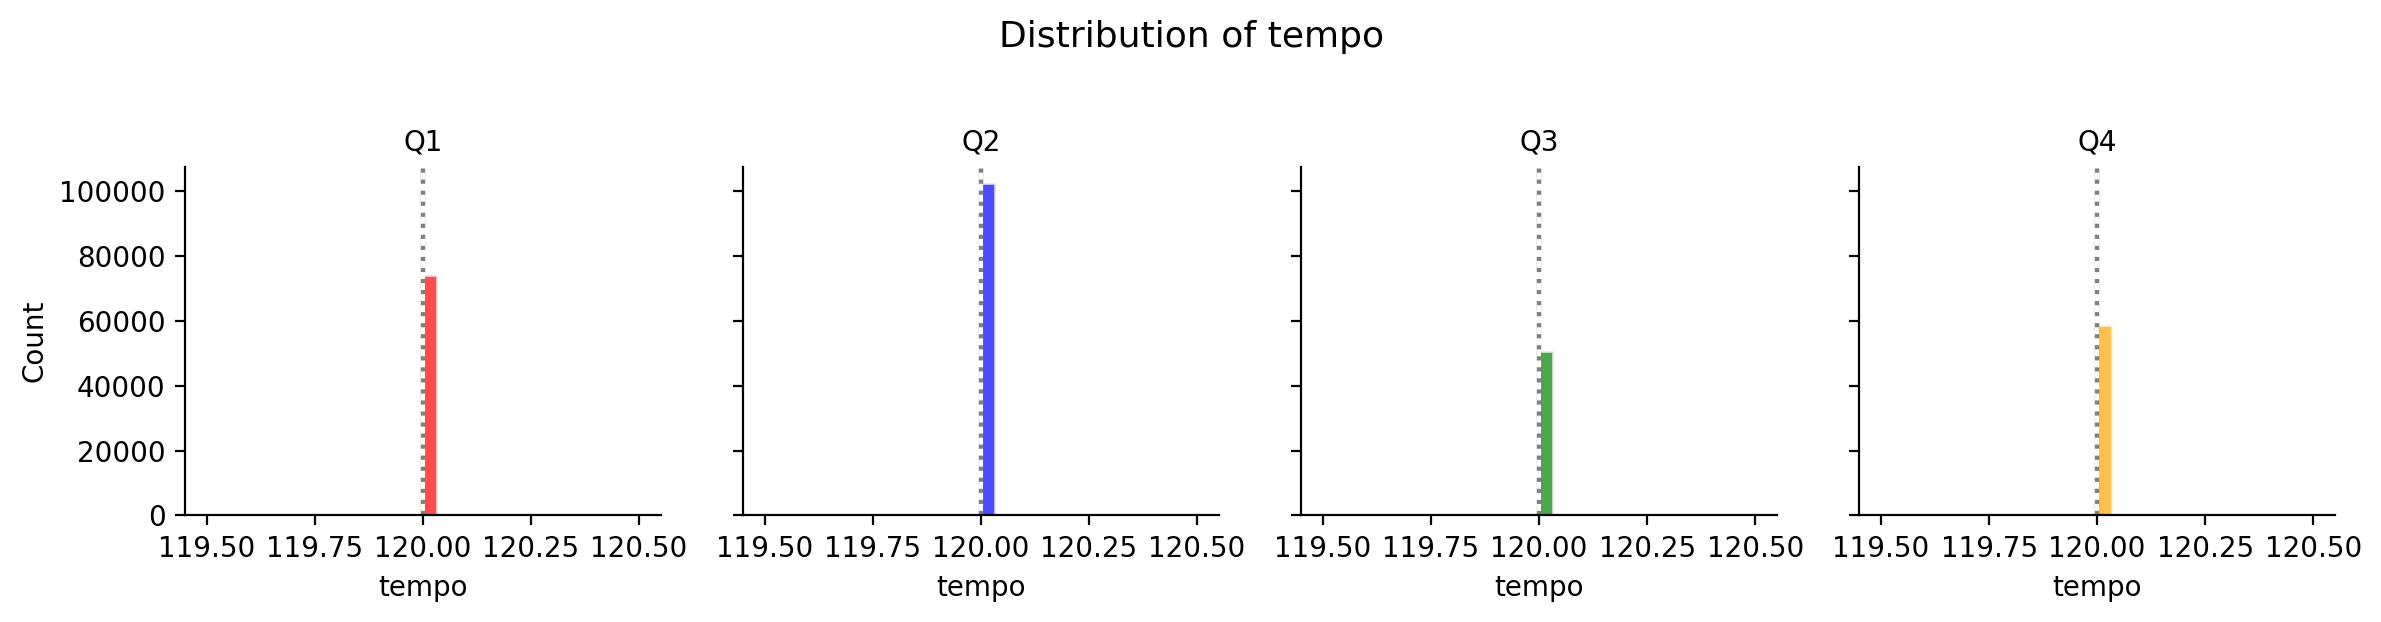

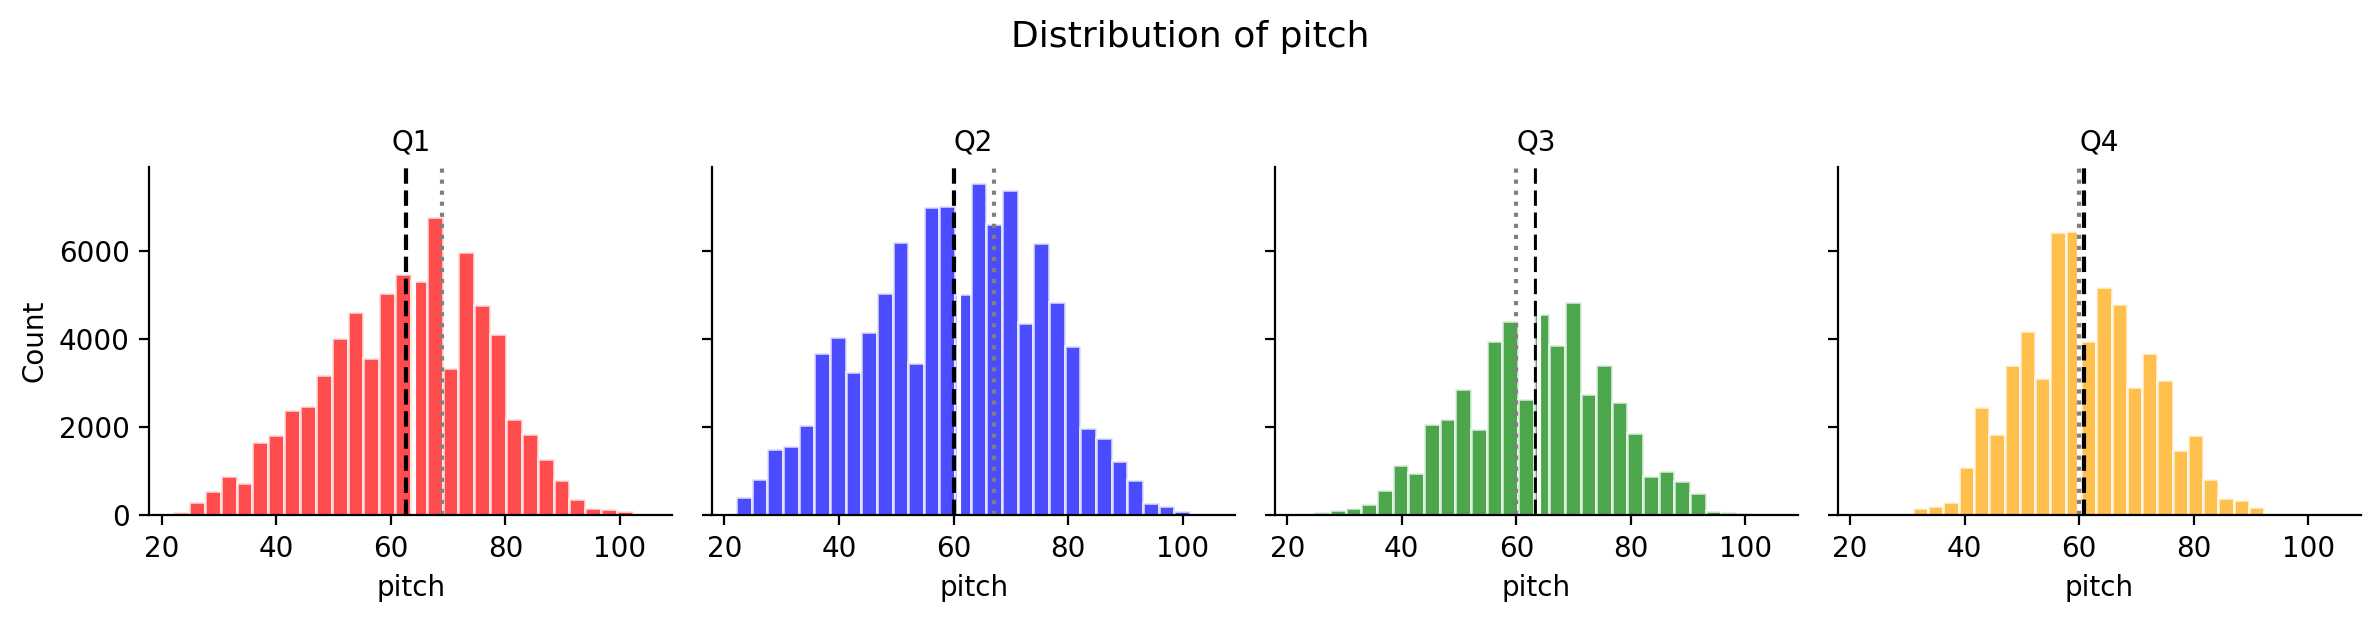

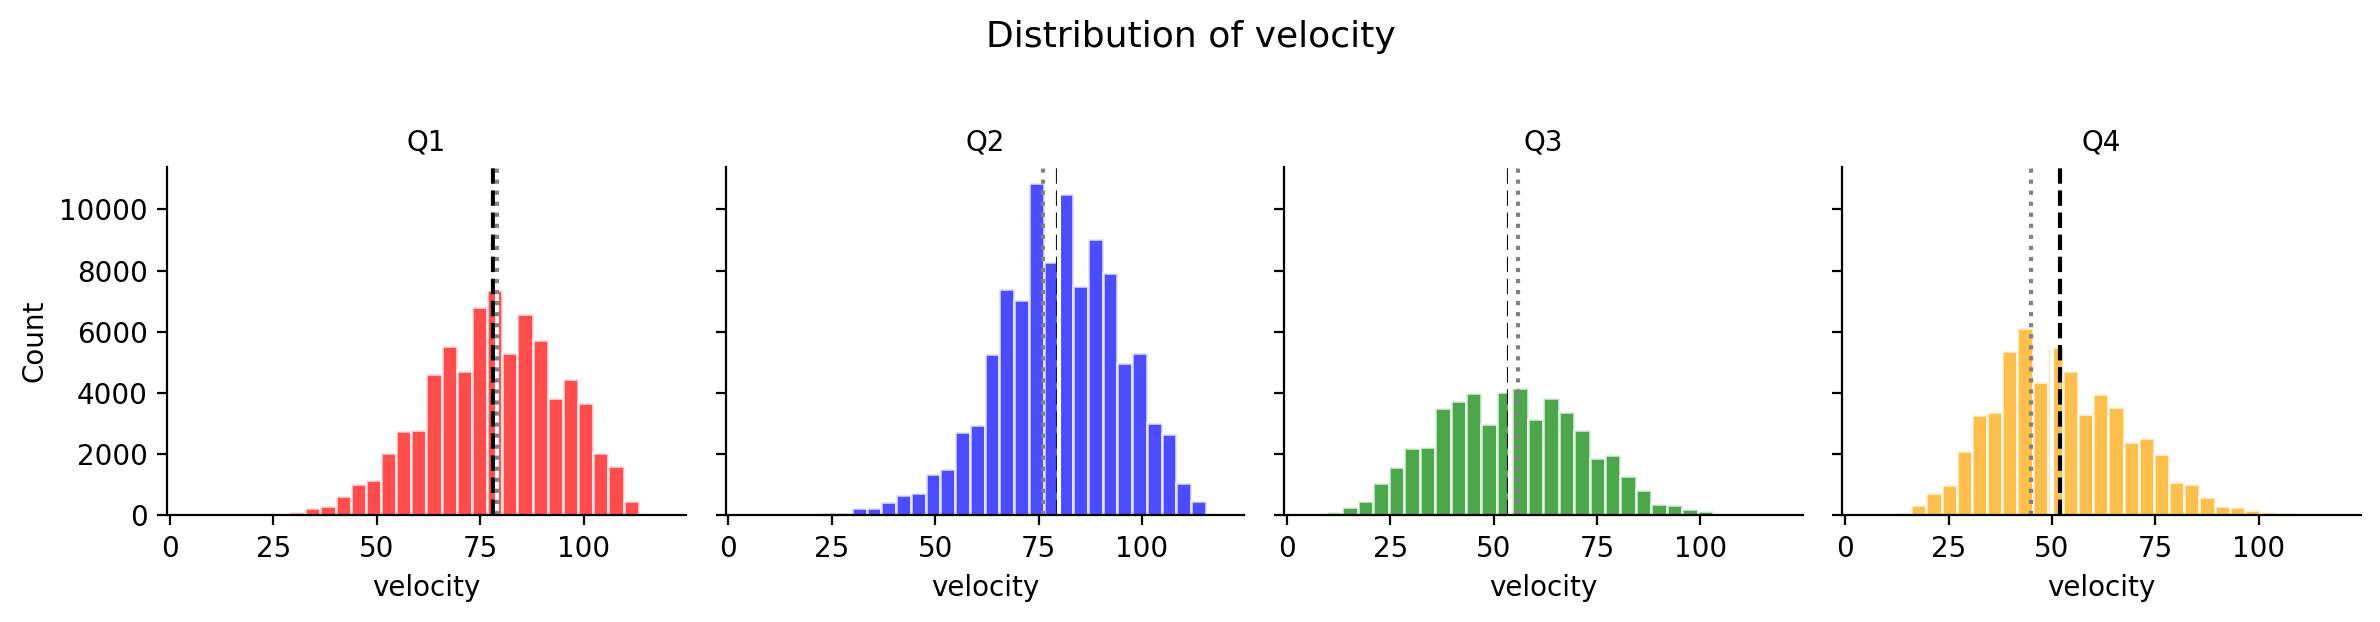

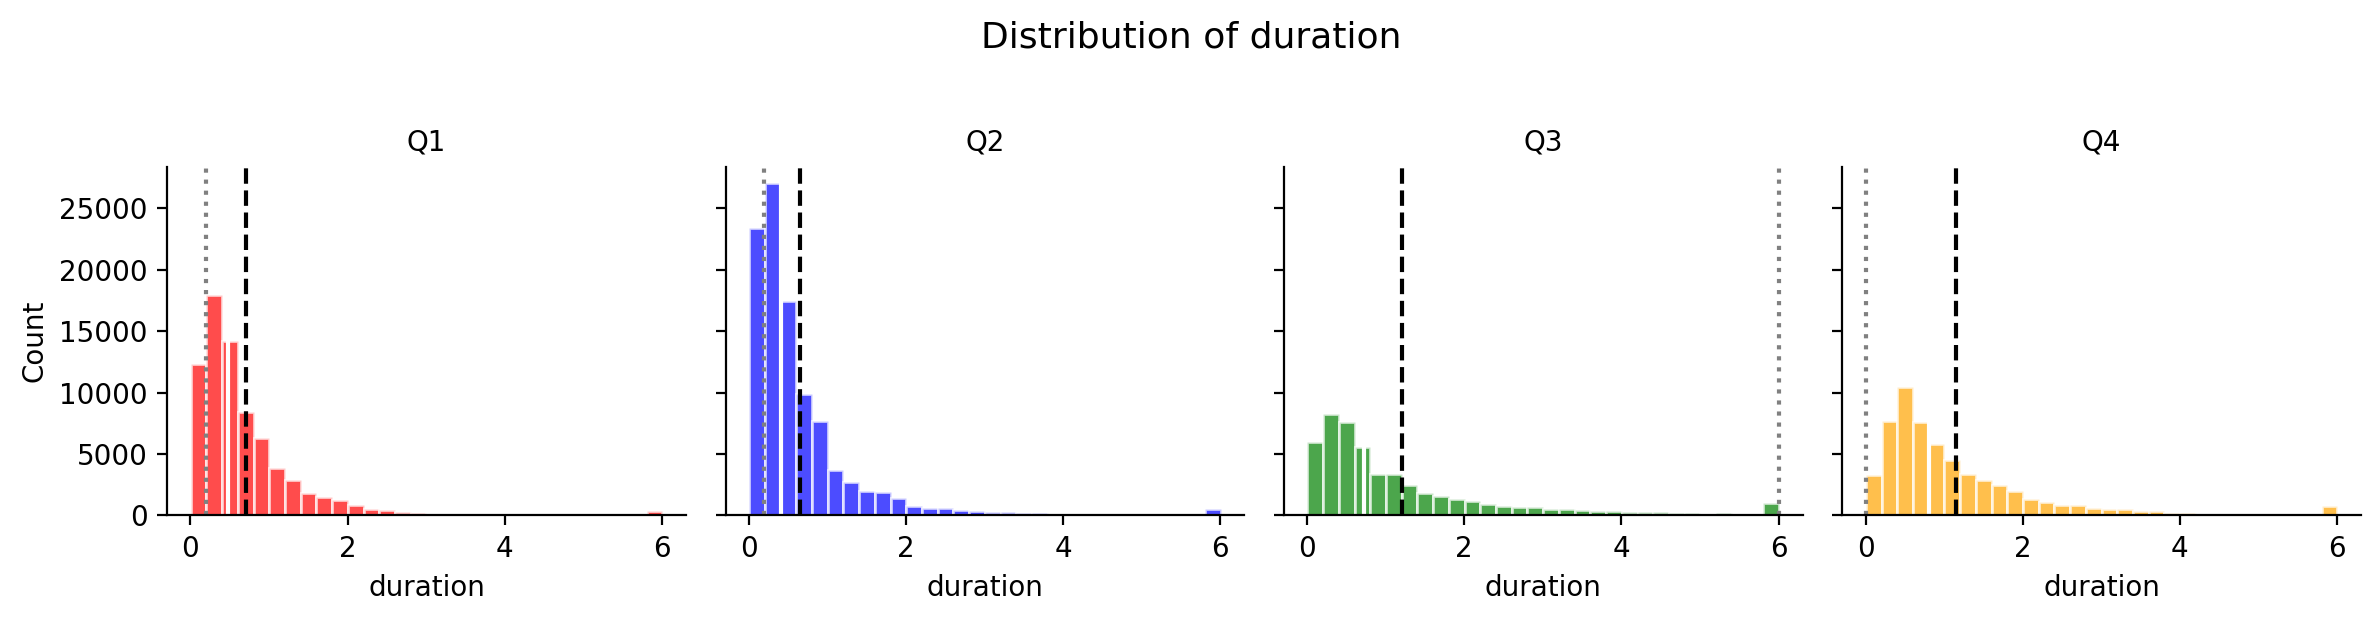

In [37]:
emopia_midi_dir = './data/emopia/midis'
pattern = r'^(Q[1-4])_.*\.mid$'

rows = []


for file in list(os.listdir(emopia_midi_dir)):
    match = re.match(pattern, file)
    if not match:
        continue

    quadrant = (match.group(1))
    midi = pretty_midi.PrettyMIDI(os.path.join(emopia_midi_dir, file))

    _, tempos = midi.get_tempo_changes()

    for instrument in midi.instruments:
        for note in instrument.notes:
            rows.append({
                'quadrant': quadrant,
                'tempo': tempos[0],
                'pitch': note.pitch,
                'velocity': note.velocity,
                'duration': note.end - note.start
            })


# Frequency distribution and Central tendency of features by quadrant
df_notes = pd.DataFrame(rows)
palette = {'Q1': 'red', 'Q2': 'blue', 'Q3': 'green', 'Q4': 'orange'}
features = ['tempo', 'pitch', 'velocity', 'duration']
q = df_notes['quadrant']

for feature in features:
    grid = sns.FacetGrid(df_notes, col='quadrant', col_order=['Q1', 'Q2', 'Q3', 'Q4'])

    
    def draw_hist(data, **kwargs):
        q      = data['quadrant'].iloc[0]
        values = data[feature].dropna()
        plt.hist(values, bins=30, color=palette[q], edgecolor='white', alpha=0.7)
        plt.axvline(values.mean(), color='black', linestyle='--', linewidth=1.5, label='Mean')
        plt.axvline(values.median(),color='white', linestyle='-',  linewidth=1.5, label='Median')
        plt.axvline(stats.mode(values, keepdims=True).mode[0], color='grey', linestyle=':',  linewidth=1.5, label='Mode')

    grid.map_dataframe(draw_hist)
    grid.set_titles(col_template='{col_name}')
    grid.set_axis_labels(feature, 'Count')
    grid.figure.suptitle(f'Distribution of {feature}', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


          

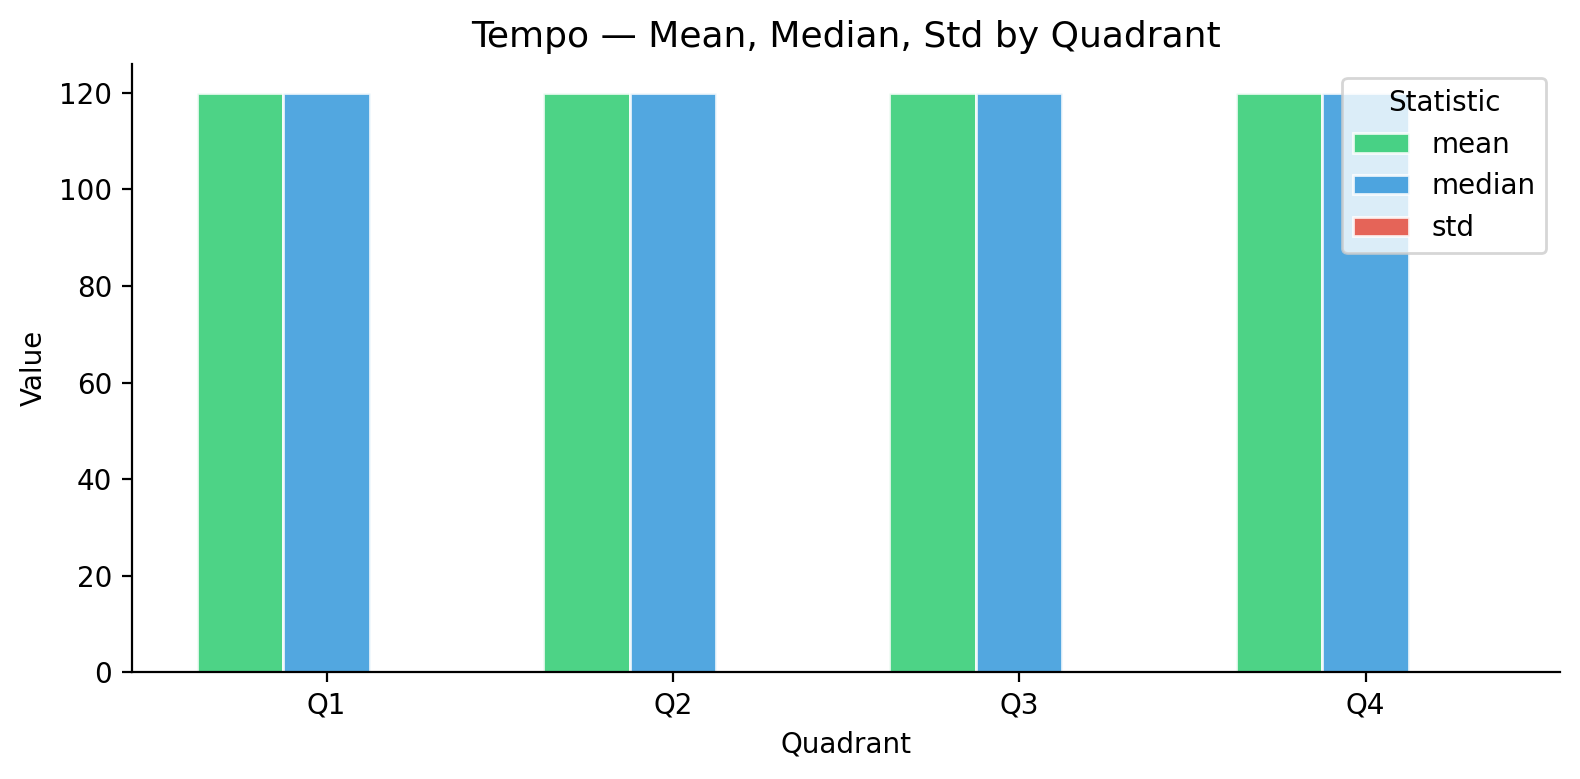

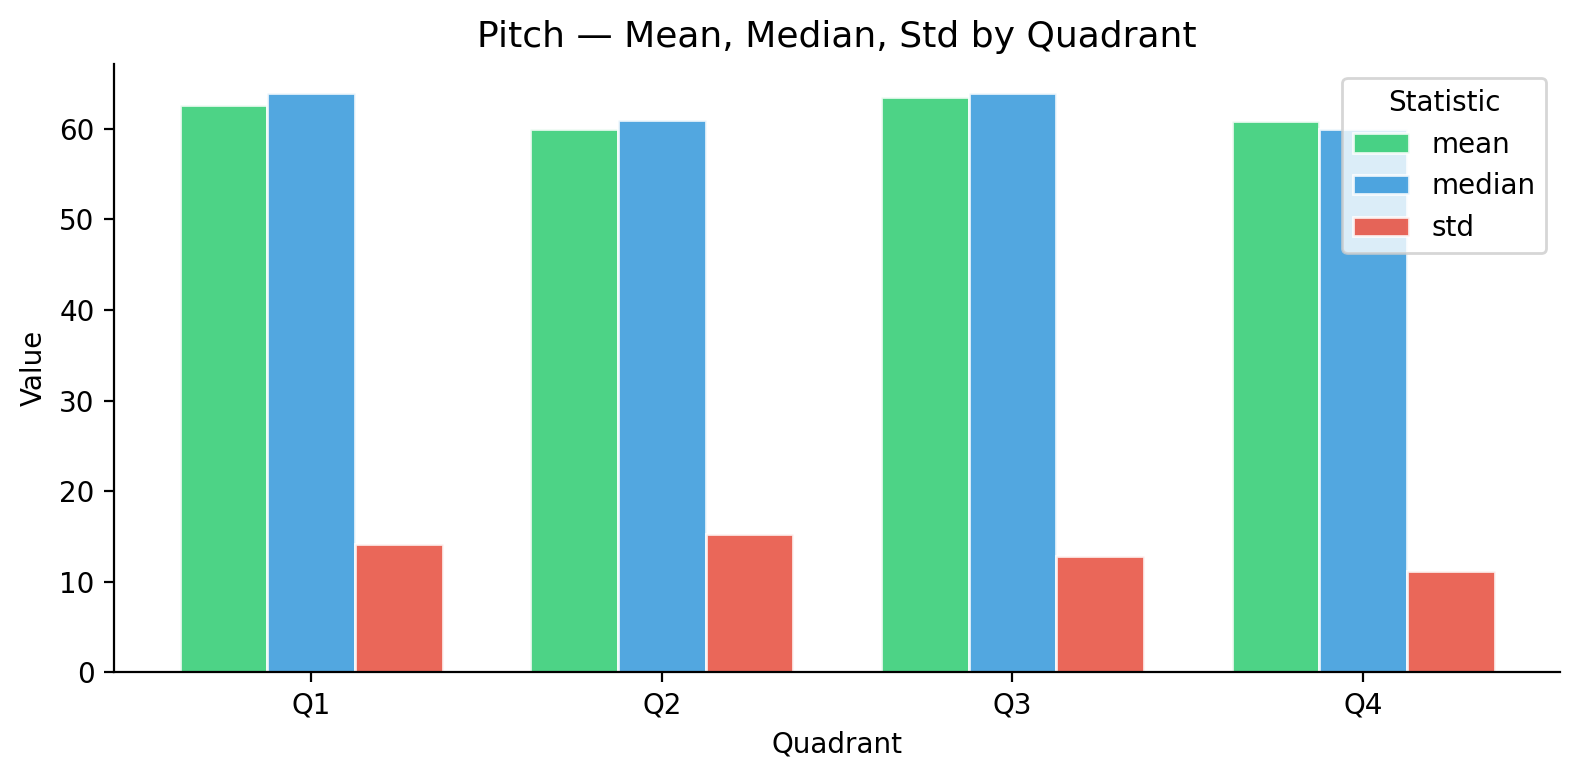

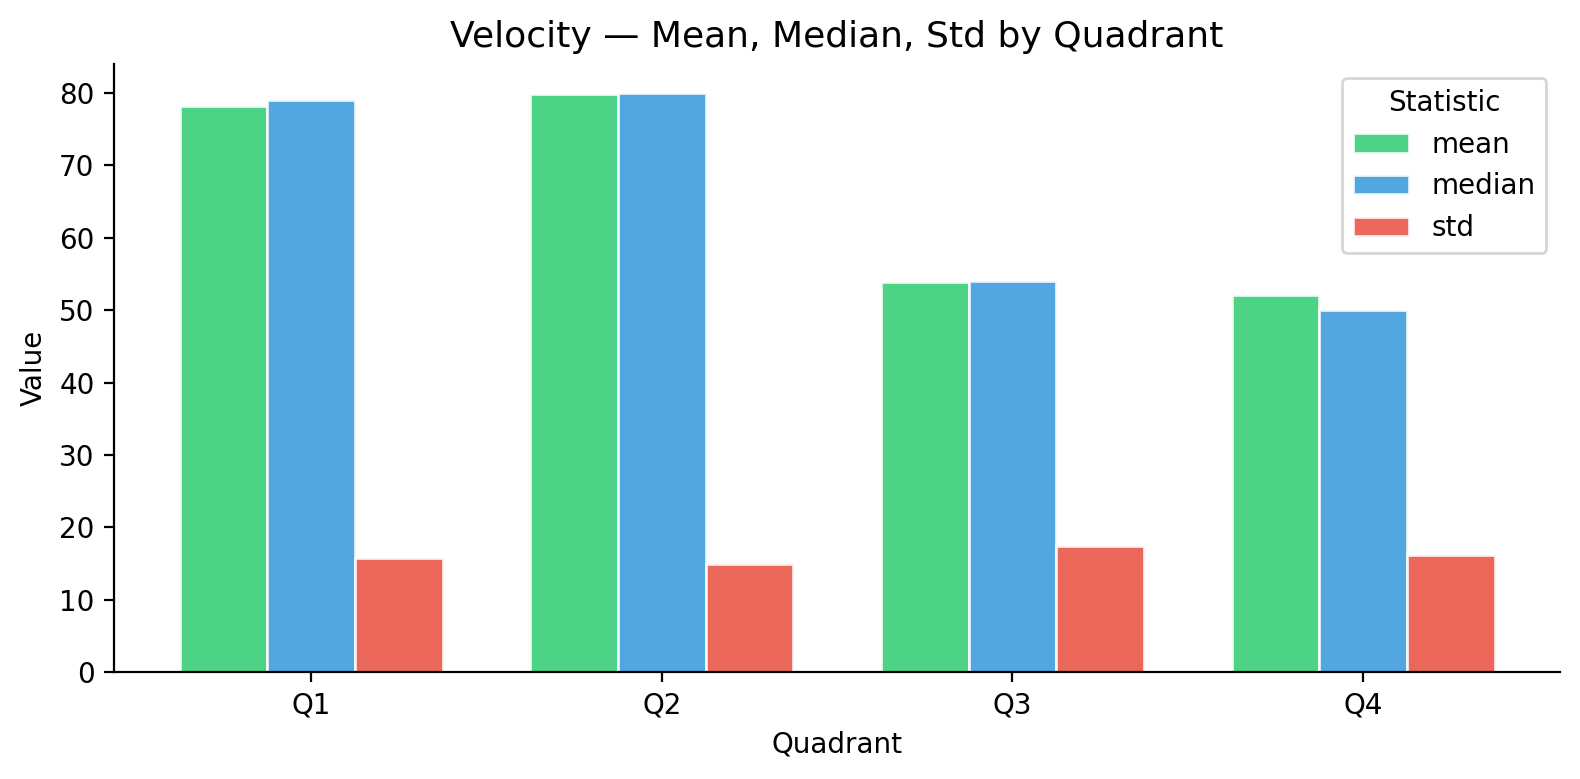

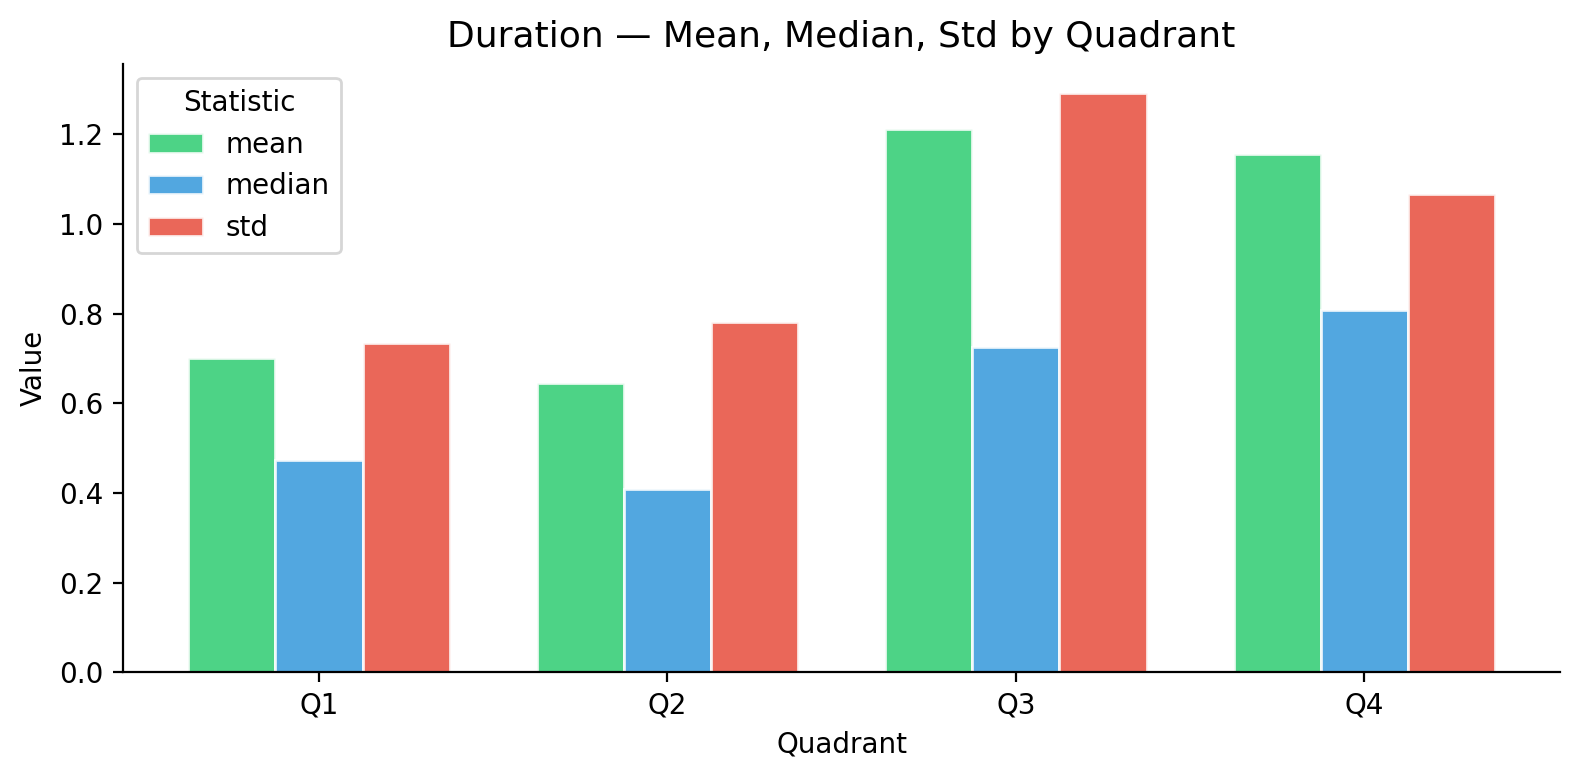

In [40]:
agg_df = df_notes.groupby('quadrant')[features].agg(['mean', 'median', 'std'])
agg_df.columns = ['_'.join(col) for col in agg_df.columns]  # e.g. 'pitch_mean'
agg_df = agg_df.loc[['Q1', 'Q2', 'Q3', 'Q4']]               # enforce order

stats   = ['mean', 'median', 'std']
colors  = {'mean': '#2ecc71', 'median': '#3498db', 'std': '#e74c3c'}
x       = np.arange(len(agg_df))   # Q1–Q4 positions
width   = 0.25                      # width of each bar

for feature in features:
    fig, ax = plt.subplots(figsize=(8, 4))

    for i, stat in enumerate(stats):
        col = f'{feature}_{stat}'
        ax.bar(x + i * width, agg_df[col], width, label=stat, color=colors[stat], edgecolor='white', alpha=0.85)

    ax.set_xticks(x + width)
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.set_title(f'{feature.capitalize()} — Mean, Median, Std by Quadrant', fontsize=13)
    ax.set_ylabel('Value')
    ax.set_xlabel('Quadrant')
    ax.legend(title='Statistic')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

- All midi data has a tempo of 120bpm. It's recommended to disregard this feature for training since it's not relevant for distinguishing emotions
- The distribution is right skewed for the duration where most notes are short but very long held notes pull the mean upward. Median is the true note length since it's not affected by outliers
- Q2 (high valence, high energy) has inconsistent note lengths since the standard deviation is higher than the mean and median. This means it has more rhythmic variety, possible fast runs with sustatined chords.
- Notes don't vary wildy within the piece, where the MIDI notes and velocities are consistent without any extreme jumps.
- More than half of the notes are short. The mean being higher is driven by a small number of long outlier notes where it's mostly staccato/detached notes.